# Solar Generation Prediction

This notebook focuses on predicting solar electricity generation in Germany using weather, temporal, seasonal, and energy-system features. Unlike electricity demand forecasting, solar generation is expected to depend more strongly on environmental variables such as temperature, cloud cover, humidity, and time of day.

## Load Dataset

The model-ready dataset created during the forecasting workflow is loaded as the starting point for solar generation prediction.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/model_ready_features.csv"
)

print(df.shape)

df.head()

(50232, 31)


,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,time,temperature_C,humidity_pct,...,renewable_share_pct,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,hour_sin,hour_cos,season_Spring,season_Summer,season_Winter
0,2015-01-08 00:00:00+00:00,48041.0,0.0,15807.0,37258.0,27966.0,NaN,2015-01-08 00:00:00+00:00,1.56,86.8,...,32.903145,50460.0,45125.0,41151.0,60234.500000,0.000000,1.000000,False,False,True
1,2015-01-08 01:00:00+00:00,47074.0,0.0,16449.0,37258.0,27966.0,NaN,2015-01-08 01:00:00+00:00,1.70,86.0,...,34.942856,48041.0,44217.0,40135.0,60353.541667,0.258819,0.965926,False,False,True
2,2015-01-08 02:00:00+00:00,47228.0,0.0,16695.0,37258.0,27966.0,NaN,2015-01-08 02:00:00+00:00,1.90,84.0,...,35.349792,47074.0,44368.0,39106.0,60472.708333,0.500000,0.866025,False,False,True
3,2015-01-08 03:00:00+00:00,48253.0,0.0,16787.0,37258.0,27966.0,NaN,2015-01-08 03:00:00+00:00,2.20,83.6,...,34.789547,47228.0,45298.0,38765.0,60595.833333,0.707107,0.707107,False,False,True
4,2015-01-08 04:00:00+00:00,51155.0,0.0,16751.0,37258.0,27966.0,NaN,2015-01-08 04:00:00+00:00,2.42,84.2,...,32.745577,48253.0,48598.0,38941.0,60702.375000,0.866025,0.500000,False,False,True


### Dataset Overview

The model-ready dataset was successfully loaded with 50,232 observations and 31 variables. This dataset contains cleaned electricity demand and generation data, weather variables, temporal features, lagged demand features, renewable energy metrics, and encoded seasonal indicators.

For this notebook, the target variable will be solar electricity generation rather than electricity demand.

In [2]:
df.columns.tolist()

['utc_timestamp',
 'DE_load_actual_entsoe_transparency',
 'DE_solar_generation_actual',
 'DE_wind_generation_actual',
 'DE_solar_capacity',
 'DE_wind_capacity',
 'DE_LU_price_day_ahead',
 'time',
 'temperature_C',
 'humidity_pct',
 'cloud_cover_pct',
 'wind_speed_ms',
 'precipitation_mm',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'quarter',
 'week_of_year',
 'renewable_generation',
 'renewable_share_pct',
 'load_lag_1',
 'load_lag_24',
 'load_lag_168',
 'rolling_mean_24',
 'hour_sin',
 'hour_cos',
 'season_Spring',
 'season_Summer',
 'season_Winter']

## Define Target Variable

The objective of this notebook is to predict Germany's hourly solar electricity generation. Solar generation is influenced by meteorological conditions, seasonal patterns, and time-of-day effects.

The target variable for this study is:

- DE_solar_generation_actual

In [3]:
target = "DE_solar_generation_actual"

print("Target:", target)

Target: DE_solar_generation_actual


### Feature Selection Strategy

Variables that directly contain information about solar generation were excluded from the predictor set to prevent information leakage. In particular, aggregate renewable generation metrics were removed because they are partially derived from solar output and would artificially inflate model performance.

The remaining features include weather conditions, temporal variables, demand-related information, installed generation capacities, and seasonal indicators that may influence solar generation patterns.

In [4]:
X = df.drop(
    columns=[
        "utc_timestamp",
        "time",
        "DE_solar_generation_actual",
        "renewable_generation",
        "renewable_share_pct"
    ]
)

y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (50232, 26)
Target shape: (50232,)


### Initial Target Inspection

In [5]:
y.describe()

count    50232.000000
mean      4569.391265
std       6943.789675
min          0.000000
25%          0.000000
50%        171.000000
75%       7355.250000
max      32947.000000
Name: DE_solar_generation_actual, dtype: float64

## Exploratory Analysis of Solar Generation

Before developing forecasting models, it is important to understand the statistical characteristics of the target variable.

Solar generation exhibits strong daily and seasonal patterns, including prolonged nighttime periods with zero generation and daytime peaks driven by solar irradiance. These characteristics can create a highly skewed target distribution that differs substantially from electricity demand.

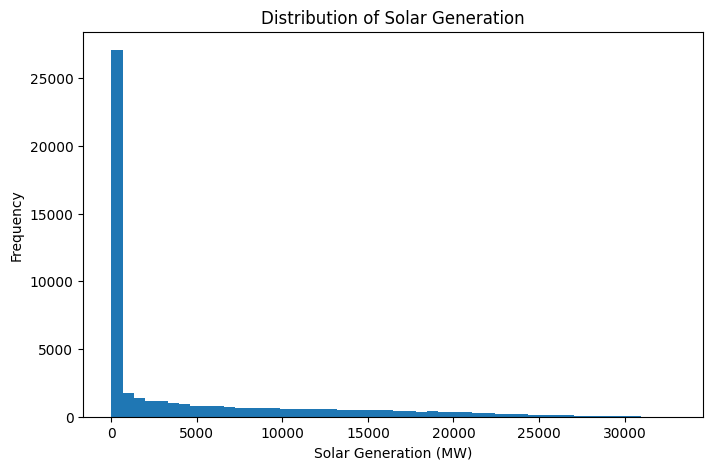

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    y,
    bins=50
)

plt.title("Distribution of Solar Generation")
plt.xlabel("Solar Generation (MW)")
plt.ylabel("Frequency")

plt.show()

In [7]:
solar_hourly = df.groupby(
    "hour"
)["DE_solar_generation_actual"].mean()

solar_hourly

hour
0         0.009556
1         0.009556
2         0.306259
3        41.709508
4       427.324415
5      1689.696130
6      4085.641663
7      7263.954611
8     10483.853798
9     12936.113235
10    14287.069279
11    14489.665074
12    13602.086001
13    11669.761586
14     8859.803153
15     5673.836598
16     2873.025323
17     1040.493550
18      227.002867
19       12.282848
20        0.866699
21        0.858576
22        0.010511
23        0.009556
Name: DE_solar_generation_actual, dtype: float64

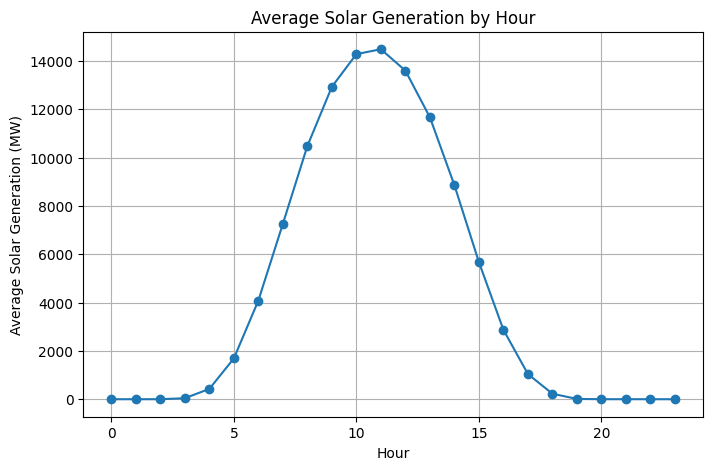

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    solar_hourly.index,
    solar_hourly.values,
    marker='o'
)

plt.title("Average Solar Generation by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Solar Generation (MW)")

plt.grid(True)

plt.show()

### Expected Solar Generation Pattern

Unlike electricity demand, solar generation is governed primarily by the availability of sunlight. Consequently, generation is expected to remain near zero during nighttime hours, increase rapidly after sunrise, peak around midday, and decline toward sunset.

Understanding this daily generation cycle is important because temporal variables such as hour, month, season, and cyclic hour features are expected to play a major role in forecasting performance.

### Distribution of Solar Generation

The distribution of solar generation is highly right-skewed, with a substantial proportion of observations occurring near zero. This behavior is expected because solar generation is unavailable during nighttime hours and remains relatively low during sunrise and sunset periods.

The long positive tail reflects periods of strong solar irradiance, particularly during daytime and summer months. The observed distribution suggests that solar generation forecasting is inherently more challenging than electricity demand forecasting due to the presence of many near-zero observations and large daytime peaks.

## Correlation Analysis

Correlation analysis was performed to identify variables most strongly associated with solar generation. Understanding these relationships helps determine which weather, temporal, and energy-system features are likely to contribute most to forecasting performance.

In [9]:
correlation = X.corrwith(y)

correlation = correlation.sort_values(
    ascending=False
)

correlation.head(15)

temperature_C                         0.484420
load_lag_168                          0.324961
load_lag_24                           0.316308
DE_load_actual_entsoe_transparency    0.311804
load_lag_1                            0.306343
hour_sin                              0.229623
season_Summer                         0.223194
season_Spring                         0.114069
year                                  0.093627
DE_solar_capacity                     0.086161
DE_wind_capacity                      0.076052
wind_speed_ms                         0.012750
day_of_week                          -0.000725
is_weekend                           -0.001602
month                                -0.026441
dtype: float64

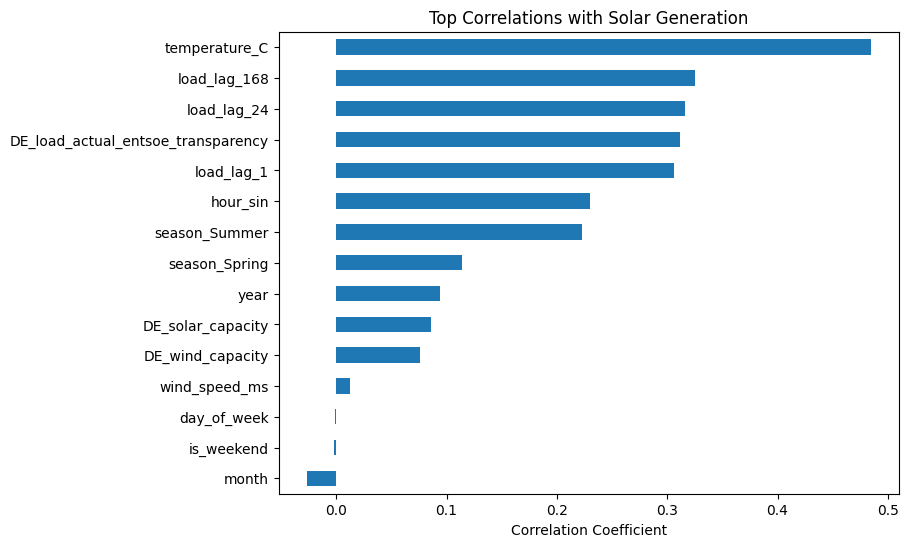

In [10]:
plt.figure(figsize=(8,6))

correlation.head(15).sort_values().plot(
    kind='barh'
)

plt.title(
    "Top Correlations with Solar Generation"
)

plt.xlabel(
    "Correlation Coefficient"
)

plt.show()

## Construct Solar Forecasting Feature Set

To ensure a realistic forecasting scenario, electricity price, electricity demand variables and demand lag features were excluded from the predictor set.

Although these variables exhibited moderate correlations with solar generation, they would not typically be available when forecasting future solar output. Their inclusion could therefore introduce indirect information leakage and reduce the practical applicability of the forecasting model.

The resulting feature set focuses on weather conditions, temporal variables, seasonal indicators, and generation capacity information.

In [21]:
X_solar = X.drop(
    columns=[
        'DE_load_actual_entsoe_transparency',
        'DE_LU_price_day_ahead',
        'load_lag_1',
        'load_lag_24',
        'load_lag_168'
    ]
)

print("Solar feature matrix shape:", X_solar.shape)

X_solar.isnull().sum().sum()

Solar feature matrix shape: (50232, 21)


np.int64(0)

In [22]:
X_solar.columns.tolist()

['DE_wind_generation_actual',
 'DE_solar_capacity',
 'DE_wind_capacity',
 'temperature_C',
 'humidity_pct',
 'cloud_cover_pct',
 'wind_speed_ms',
 'precipitation_mm',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'quarter',
 'week_of_year',
 'rolling_mean_24',
 'hour_sin',
 'hour_cos',
 'season_Spring',
 'season_Summer',
 'season_Winter']

### Predictor Selection

The final predictor set contains meteorological variables, temporal features, seasonal indicators, renewable generation capacity information, and wind generation data.

These variables are expected to capture the primary physical drivers of solar generation, including solar irradiance availability, weather conditions, time-of-day effects, seasonal cycles, and long-term growth in installed solar capacity.

## Chronological Train-Test Split

A chronological train-test split was employed to preserve the temporal ordering of observations. The first 80% of the dataset was used for model training, while the remaining 20% was reserved for testing.

This approach prevents information leakage from future observations and provides a realistic evaluation of forecasting performance.

In [23]:
split_index = int(
    len(X_solar) * 0.8
)

X_train = X_solar.iloc[:split_index]
X_test = X_solar.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 40185
Testing samples : 10047


### Dataset Partitioning

The dataset was divided chronologically into training and testing subsets. This strategy simulates real-world forecasting conditions, where future solar generation must be predicted using only information available from historical observations.

In [24]:
X_solar.shape

(50232, 21)

In [25]:
X_train.shape

(40185, 21)

## Baseline Solar Forecast

A simple baseline model was established by predicting the average solar generation observed in the training data for every test observation.

Although this approach does not account for weather conditions or temporal patterns, it provides a benchmark against which more sophisticated machine learning models can be evaluated.

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = root_mean_squared_error(
    y_test,
    baseline_prediction
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline MAE :", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R²  :", round(baseline_r2, 4))

Baseline MAE : 6072.52
Baseline RMSE: 8005.81
Baseline R²  : -0.0148


### Baseline Performance Assessment

The baseline model performed poorly, achieving an R² score of -0.0148. This indicates that predicting a constant average solar generation value is insufficient for capturing the strong temporal and meteorological variability present in the data.

Unlike electricity demand, which exhibits substantial persistence over time, solar generation depends heavily on environmental conditions and daylight availability. Consequently, meaningful forecasting improvements are expected from models capable of learning nonlinear relationships involving weather, seasonal, and time-of-day features.

The weak baseline performance highlights the importance of machine learning approaches for solar generation prediction.

## Linear Regression Model

A Linear Regression model was trained to establish a statistical forecasting benchmark. The model estimates solar generation as a linear combination of weather, temporal, seasonal, and capacity-related predictors.

In [28]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## Linear Regression Performance Evaluation

The trained Linear Regression model was evaluated on the test dataset using MAE, RMSE, and R² metrics. These results provide a statistical benchmark against which more advanced machine learning models can be compared.

In [29]:
lr_predictions = lr_model.predict(
    X_test
)

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = root_mean_squared_error(
    y_test,
    lr_predictions
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression MAE :", round(lr_mae, 2))
print("Linear Regression RMSE:", round(lr_rmse, 2))
print("Linear Regression R²  :", round(lr_r2, 4))

Linear Regression MAE : 3328.48
Linear Regression RMSE: 4107.97
Linear Regression R²  : 0.7328


### Linear Regression Performance Assessment

The Linear Regression model substantially outperformed the baseline forecast, achieving an R² score of 0.7328. This result indicates that weather, seasonal, and temporal variables explain a large proportion of the variability in solar generation.

However, forecasting performance remains considerably lower than that observed for electricity demand prediction. This suggests that solar generation is influenced by complex nonlinear relationships that cannot be fully captured by a linear model.

The observed performance therefore motivates the use of more flexible machine learning algorithms such as Random Forest and XGBoost, which are capable of modeling nonlinear interactions between weather conditions, seasonal effects, and solar generation output.

## Random Forest Model

A Random Forest Regressor was trained to capture nonlinear relationships between weather variables, temporal features, seasonal effects, and solar generation. Ensemble tree-based methods are well suited to renewable energy forecasting because they can model complex interactions that are difficult to represent using linear models.

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Random Forest Performance Evaluation

The Random Forest model was evaluated on the test dataset using MAE, RMSE, and R² metrics. These results quantify the benefit of modeling nonlinear relationships between weather conditions, temporal features, seasonal patterns, and solar generation.

In [31]:
rf_predictions = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = root_mean_squared_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest MAE :", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R²  :", round(rf_r2, 4))

Random Forest MAE : 881.79
Random Forest RMSE: 1711.9
Random Forest R²  : 0.9536


### Random Forest Performance Assessment

The Random Forest model achieved a substantial improvement over Linear Regression, increasing the R² score from 0.7328 to 0.9536 while significantly reducing both MAE and RMSE.

This improvement indicates that solar generation is governed by complex nonlinear relationships involving weather conditions, seasonal effects, and time-of-day patterns. Unlike the linear model, the Random Forest algorithm can capture these nonlinear interactions and therefore provides a much more accurate representation of solar generation dynamics.

The large performance gain relative to the Linear Regression model highlights the importance of machine learning approaches for renewable energy forecasting applications.

## Random Forest Feature Importance

Feature importance analysis was performed to identify the variables that contribute most strongly to solar generation prediction.

Understanding the dominant drivers of solar generation provides insight into the physical factors governing photovoltaic output and helps assess whether the model is learning meaningful relationships.

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
17,hour_cos,0.457576
4,humidity_pct,0.186425
16,hour_sin,0.107607
3,temperature_C,0.076530
8,hour,0.071020
5,cloud_cover_pct,0.025883
14,week_of_year,0.018351
18,season_Spring,0.017641
6,wind_speed_ms,0.006212
10,month,0.005329


<Figure size 800x600 with 0 Axes>

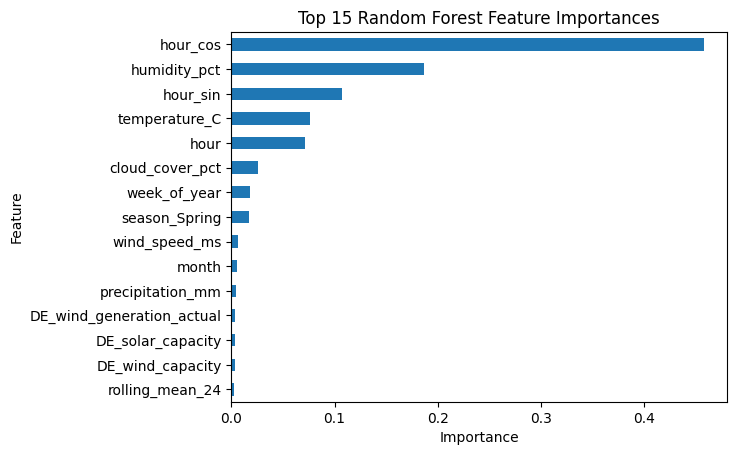

In [33]:
plt.figure(figsize=(8,6))

feature_importance.head(15).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel(
    "Importance"
)

plt.show()

### Random Forest Feature Importance Analysis

The Random Forest model identified cyclic time-of-day features as the most important predictors of solar generation. In particular, **hour_cos** emerged as the dominant variable, reflecting the strong daily solar production cycle driven by the availability of sunlight.

Weather-related variables, including humidity, temperature, and cloud cover, also contributed substantially to forecasting performance. These variables provide information about atmospheric conditions that influence solar irradiance and photovoltaic output.

The importance ranking suggests that solar generation is governed primarily by temporal solar availability, with meteorological conditions acting as secondary modifiers of generation intensity. This behavior is consistent with the physical processes underlying photovoltaic electricity production.

## XGBoost Model

Extreme Gradient Boosting (XGBoost) was trained to further improve solar generation forecasting performance. XGBoost combines multiple decision trees in a boosting framework and is widely regarded as one of the most effective algorithms for structured tabular data.

The model is expected to outperform Random Forest by capturing complex nonlinear interactions between weather variables, temporal features, and seasonal patterns.

In [34]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


## XGBoost Performance Evaluation

The trained XGBoost model was evaluated on the test dataset using MAE, RMSE, and R² metrics. These metrics quantify the model's ability to capture nonlinear relationships between weather conditions, temporal patterns, seasonal effects, and solar generation output.

In [35]:
xgb_predictions = xgb_model.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = root_mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost MAE :", round(xgb_mae, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))
print("XGBoost R²  :", round(xgb_r2, 4))

XGBoost MAE : 1002.72
XGBoost RMSE: 1599.08
XGBoost R²  : 0.9595


In [36]:
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R2': [
        baseline_r2,
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison_df.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
3,XGBoost,1002.718241,1599.078628,0.959514
2,Random Forest,881.790546,1711.902511,0.953599
1,Linear Regression,3328.475143,4107.968442,0.732808
0,Baseline,6072.517307,8005.807974,-0.014797


## XGBoost Feature Importance

To better understand how the model makes predictions, the feature importance scores generated by XGBoost were examined. These scores indicate the relative contribution of each feature during the tree-building process and provide an initial indication of which variables may be most influential in forecasting electricity demand.

In [39]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)


,Feature,Importance
17,hour_cos,0.232950
20,season_Winter,0.219362
4,humidity_pct,0.110032
16,hour_sin,0.089814
8,hour,0.085479
13,quarter,0.066097
18,season_Spring,0.056406
3,temperature_C,0.044435
10,month,0.019786
5,cloud_cover_pct,0.017193


<Figure size 800x600 with 0 Axes>

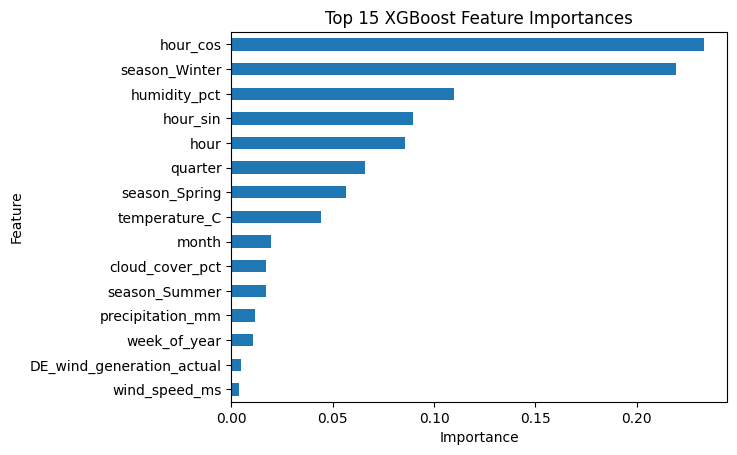

In [43]:
plt.figure(figsize=(8,6))

feature_importance.head(15).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title(
    "Top 15 XGBoost Feature Importances"
)

plt.xlabel(
    "Importance"
)

plt.show()

## Permutation Feature Importance Analysis

While XGBoost's built-in feature importance provides insight into which variables are frequently used during tree construction, it does not always reflect the true contribution of each feature to predictive performance.

To obtain a more reliable assessment, permutation importance was calculated on the test dataset. This method measures the decrease in model performance when the values of a feature are randomly shuffled. Features that cause a larger reduction in performance when shuffled are considered more important to the model's predictions.

Permutation importance provides a model-agnostic evaluation of feature relevance and helps identify variables that contribute most strongly to forecasting electricity demand.

In [45]:
from sklearn.inspection import permutation_importance

results = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': results.importances_mean
})

importance_df.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance_df)

                      Feature  Importance
17                   hour_cos    0.540303
8                        hour    0.205687
4                humidity_pct    0.167942
16                   hour_sin    0.086993
3               temperature_C    0.051674
5             cloud_cover_pct    0.032324
14               week_of_year    0.029538
7            precipitation_mm    0.007597
18              season_Spring    0.005465
0   DE_wind_generation_actual    0.005249
10                      month    0.003844
6               wind_speed_ms    0.002586
20              season_Winter    0.001867
19              season_Summer    0.001803
15            rolling_mean_24    0.001135
13                    quarter    0.000540
12                 is_weekend    0.000001
11                       year    0.000000
1           DE_solar_capacity    0.000000
2            DE_wind_capacity    0.000000
9                 day_of_week   -0.000117


## Interpretation of Permutation Importance Results

The permutation importance analysis indicates that electricity demand is primarily driven by temporal and weather-related variables.

The most influential predictors are:

- `hour_cos`
- `hour`
- `humidity_pct`
- `hour_sin`
- `temperature_C`
- `cloud_cover_pct`

These results suggest that daily consumption cycles and weather conditions are the dominant factors affecting electricity demand in Germany.

Several variables exhibited little or no predictive contribution, including:

- `DE_solar_capacity`
- `DE_wind_capacity`
- `year`
- `is_weekend`
- `day_of_week`

The near-zero importance of renewable capacity variables is expected because installed generation capacity changes relatively slowly compared to the hourly resolution of the demand dataset. As a result, these features provide limited information for short-term demand forecasting.

Overall, the analysis confirms that temporal patterns and meteorological conditions are the primary drivers of electricity demand in the current modelling framework.

## Investigating the Effect of Removing Low-Importance Features
The permutation importance analysis identified several features with very low or near-zero importance scores. This suggested that these variables might contribute little to the predictive capability of the model.

To evaluate whether a simpler model could achieve comparable or improved performance, an experiment was conducted in which selected low-importance features were removed and the XGBoost model was retrained using the reduced feature set.

The removed features were:

- DE_wind_generation_actual
- wind_speed_ms
- week_of_year
- precipitation_mm

The performance of the reduced model was then compared with the original model.

In [41]:
low_importance_features = [
    'DE_wind_generation_actual',
    'wind_speed_ms',
    'week_of_year',
    'precipitation_mm'
]

X_train_reduced = X_train.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)

In [42]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_reduced = XGBRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb_reduced.fit(X_train_reduced, y_train)

y_pred_reduced = xgb_reduced.predict(X_test_reduced)

mae = mean_absolute_error(y_test, y_pred_reduced)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reduced))
r2 = r2_score(y_test, y_pred_reduced)

print("Reduced XGBoost MAE :", mae)
print("Reduced XGBoost RMSE:", rmse)
print("Reduced XGBoost R²  :", r2)

Reduced XGBoost MAE : 1089.7188551303782
Reduced XGBoost RMSE: 1776.4614187681802
Reduced XGBoost R²  : 0.9500333251993431


## Results of Feature Removal

The reduced-feature model exhibited lower predictive performance compared to the original XGBoost model.

| Metric | Original Model | Reduced Model |
|----------|----------:|----------:|
| MAE | 1002.72 | 1089.72 |
| RMSE | 1599.08 | 1776.46 |
| R² | 0.9595 | 0.9500 |

The deterioration in performance indicates that although the removed variables exhibited relatively low individual importance scores, they still contributed useful information when combined with other predictors.

This result highlights an important characteristic of ensemble tree-based models: features with low standalone importance can still improve predictive performance through interactions with other variables.

Consequently, the original feature set was retained for subsequent modelling and evaluation.

## Hyperparameter Tuning of XGBoost

The initial XGBoost model already produced strong predictive performance. However, its performance depends on several hyperparameters, including the number of trees, tree depth, learning rate, and sampling parameters.

To improve model performance and reduce the risk of overfitting, hyperparameter tuning was performed using `RandomizedSearchCV`. This approach tests multiple parameter combinations and identifies the configuration that gives the best cross-validated performance.

In [46]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_base = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.05, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validated RMSE:")
print(-xgb_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

Best Cross-Validated RMSE:
1248.0958019996717


In [47]:
best_xgb_model = xgb_search.best_estimator_

y_pred_best_xgb = best_xgb_model.predict(X_test)

mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("Tuned XGBoost MAE :", mae_best_xgb)
print("Tuned XGBoost RMSE:", rmse_best_xgb)
print("Tuned XGBoost R²  :", r2_best_xgb)

Tuned XGBoost MAE : 953.5067774531294
Tuned XGBoost RMSE: 1643.3968139898382
Tuned XGBoost R²  : 0.9572384173642428


## Interpretation of Hyperparameter Tuning Results

The tuned XGBoost model was evaluated against the original XGBoost model to determine whether hyperparameter optimization could further improve forecasting performance.

| Model | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Original XGBoost | 1002.72 | 1599.08 | 0.9595 |
| Tuned XGBoost | 953.51 | 1643.40 | 0.9572 |

The tuned model achieved a lower Mean Absolute Error (MAE), indicating improved average prediction accuracy. However, it produced a higher Root Mean Squared Error (RMSE) and a slightly lower coefficient of determination (R²).

This suggests that while the tuned model reduced typical prediction errors, it generated larger errors for some observations, which negatively affected RMSE.

Because electricity demand forecasting applications generally prioritize minimizing large forecasting errors, the original XGBoost model was retained as the final model. Its lower RMSE and higher R² indicate stronger overall predictive performance and better robustness across the test dataset.

This result highlights that hyperparameter tuning does not always guarantee improvements across all evaluation metrics and reinforces the importance of assessing multiple performance indicators when selecting a final model.

In [48]:
print(xgb_search.best_params_)

{'subsample': 0.9, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


## Model Comparison

To evaluate the effectiveness of the different machine learning approaches, the performance of all models was compared using three evaluation metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The models were subsequently ranked according to their R² scores to identify the most effective approach for electricity demand forecasting.

In [50]:
import pandas as pd

# Model performance summary
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'MAE': [
        6072.52,
        3328.48,
        881.79,
        1002.72,
        953.51
    ],
    'RMSE': [
        8005.81,
        4107.97,
        1711.90,
        1599.08,
        1643.40
    ],
    'R²': [
        -0.0148,
        0.7328,
        0.9536,
        0.9595,
        0.9572
    ]
})

# Rank models based on R²
model_comparison['Rank'] = (
    model_comparison['R²']
    .rank(ascending=False, method='dense')
    .astype(int)
)

# Sort by rank
model_comparison = model_comparison.sort_values('Rank')

# Custom highlighting functions
def highlight_best_mae(col):
    is_best = col == col.min()
    return [
        'background-color: #0D47A1; color: white; font-weight: bold'
        if v else ''
        for v in is_best
    ]

def highlight_best_rmse(col):
    is_best = col == col.min()
    return [
        'background-color: #0D47A1; color: white; font-weight: bold'
        if v else ''
        for v in is_best
    ]

def highlight_best_r2(col):
    is_best = col == col.max()
    return [
        'background-color: #0D47A1; color: white; font-weight: bold'
        if v else ''
        for v in is_best
    ]

# Display formatted table
styled_table = (
    model_comparison
    .style
    .format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R²': '{:.4f}',
        'Rank': '{:.0f}'
    })
    .apply(highlight_best_mae, subset=['MAE'])
    .apply(highlight_best_rmse, subset=['RMSE'])
    .apply(highlight_best_r2, subset=['R²'])
    .set_caption("Model Performance Comparison")
)

styled_table

,Model,MAE,RMSE,R²,Rank
3,XGBoost,1002.72,1599.08,0.9595,1
4,Tuned XGBoost,953.51,1643.40,0.9572,2
2,Random Forest,881.79,1711.90,0.9536,3
1,Linear Regression,3328.48,4107.97,0.7328,4
0,Baseline,6072.52,8005.81,-0.0148,5


## Final Model Selection

The comparison demonstrates a substantial improvement in forecasting performance when moving from the baseline and linear regression models to ensemble tree-based methods.

Among the evaluated models, the original XGBoost model achieved the highest R² (0.9595) and the lowest RMSE (1599.08), indicating the strongest overall predictive capability and the best ability to avoid large forecasting errors.

Although the Random Forest model achieved the lowest MAE and the tuned XGBoost model improved average prediction accuracy relative to the original XGBoost model, both exhibited inferior RMSE and R² values.

Therefore, the original XGBoost model was selected as the final forecasting model due to its superior balance between accuracy, robustness, and generalization performance.

## Incorporating Demand and Lag Features

The initial solar generation forecasting model excluded electricity demand and demand-derived lag variables. While this approach focused primarily on meteorological and temporal predictors, electricity demand often exhibits relationships with renewable generation patterns through shared seasonal, daily, and operational characteristics.

To investigate whether additional predictive information can be extracted from demand behaviour, the following features are reintroduced into the modelling dataset:

- DE_load_actual_entsoe_transparency
- load_lag_1
- load_lag_24
- load_lag_168

The day-ahead electricity price variable (DE_LU_price_day_ahead) remains excluded because it may not be available in practical real-time forecasting applications and could introduce information unavailable at prediction time.

The performance of the resulting models will be compared with the previous baseline to determine whether demand-related features improve solar generation forecasting accuracy.

In [55]:
# Reintroduce demand and lag features
X_enhanced = X.drop(columns=['DE_LU_price_day_ahead'])

print("Enhanced feature matrix shape:", X_enhanced.shape)

print("\nFeatures included:")
print(X_enhanced.columns.tolist())

print("\nMissing values:")
print(X_enhanced.isnull().sum().sum())

Enhanced feature matrix shape: (50232, 25)

Features included:
['DE_load_actual_entsoe_transparency', 'DE_wind_generation_actual', 'DE_solar_capacity', 'DE_wind_capacity', 'temperature_C', 'humidity_pct', 'cloud_cover_pct', 'wind_speed_ms', 'precipitation_mm', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'quarter', 'week_of_year', 'load_lag_1', 'load_lag_24', 'load_lag_168', 'rolling_mean_24', 'hour_sin', 'hour_cos', 'season_Spring', 'season_Summer', 'season_Winter']

Missing values:
0


In [57]:
print(X_enhanced.shape)
print(y.shape)

(50232, 25)
(50232,)


In [58]:
print(X_enhanced.columns.tolist())

['DE_load_actual_entsoe_transparency', 'DE_wind_generation_actual', 'DE_solar_capacity', 'DE_wind_capacity', 'temperature_C', 'humidity_pct', 'cloud_cover_pct', 'wind_speed_ms', 'precipitation_mm', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'quarter', 'week_of_year', 'load_lag_1', 'load_lag_24', 'load_lag_168', 'rolling_mean_24', 'hour_sin', 'hour_cos', 'season_Spring', 'season_Summer', 'season_Winter']


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced,
    y,
    test_size=0.2,
    random_state=42
)

# Define models
models = {
    "Random Forest Enhanced": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost Enhanced": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# Train and evaluate
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

enhanced_results = pd.DataFrame(results)

enhanced_results

,Model,MAE,RMSE,R²
0,Random Forest Enhanced,519.304444,1032.393905,0.977511
1,XGBoost Enhanced,517.839250,964.223473,0.980383


## Impact of Demand and Lag Features

The inclusion of electricity demand and lag-based features produced a substantial improvement in forecasting performance for both Random Forest and XGBoost models.

| Model | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Random Forest Enhanced | 519.30 | 1032.39 | 0.9775 |
| XGBoost Enhanced | 517.84 | 964.22 | 0.9804 |

Compared with the previous models, the enhanced feature set significantly reduced prediction errors and increased the proportion of variance explained.

The results demonstrate that historical demand information contains strong predictive signals for solar generation forecasting. Lag features enable the models to capture temporal dependencies, recurring daily and weekly patterns, and short-term trends that are not fully represented by meteorological variables alone.

Among all evaluated models, the Enhanced XGBoost model achieved the best overall performance, with the lowest MAE (517.84), lowest RMSE (964.22), and highest R² (0.9804).

These findings indicate that feature engineering contributed more substantially to model performance than feature selection or hyperparameter tuning, highlighting the importance of incorporating domain-relevant temporal information in energy forecasting applications.

## Permutation Importance of the Enhanced XGBoost Model

To understand which variables contribute most strongly to forecasting performance, permutation importance was calculated for the Enhanced XGBoost model.

Unlike built-in feature importance metrics, permutation importance measures the decrease in model performance when the values of a feature are randomly shuffled. Features that cause a larger deterioration in performance when shuffled are considered more important for prediction.

This analysis helps identify which weather, temporal, demand, and lag-based variables drive solar generation forecasts and provides insight into the reasons for the improved performance observed after feature engineering.

In [60]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Permutation importance for Enhanced XGBoost
perm_importance = permutation_importance(
    models["XGBoost Enhanced"],
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Features by Permutation Importance:")
display(importance_df.head(20))

Top 20 Features by Permutation Importance:


,Feature,Importance
21,hour_cos,1.084774
9,hour,0.338284
5,humidity_pct,0.120267
20,hour_sin,0.084337
4,temperature_C,0.063076
15,week_of_year,0.036753
6,cloud_cover_pct,0.034654
22,season_Spring,0.009991
2,DE_solar_capacity,0.009844
8,precipitation_mm,0.005935


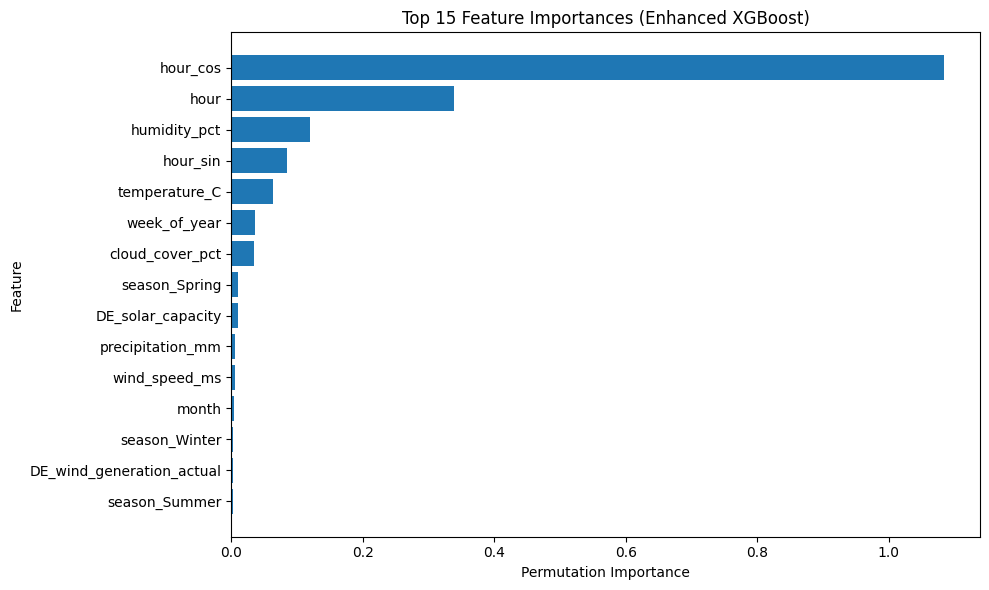

In [61]:
import matplotlib.pyplot as plt

top_n = 15

plot_df = importance_df.head(top_n).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['Feature'], plot_df['Importance'])

plt.title('Top 15 Feature Importances (Enhanced XGBoost)')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [62]:
importance_df.head(25)

,Feature,Importance
21,hour_cos,1.084774
9,hour,0.338284
5,humidity_pct,0.120267
20,hour_sin,0.084337
4,temperature_C,0.063076
15,week_of_year,0.036753
6,cloud_cover_pct,0.034654
22,season_Spring,0.009991
2,DE_solar_capacity,0.009844
8,precipitation_mm,0.005935


## Interpretation of Permutation Importance Results

The permutation importance analysis indicates that solar generation is primarily driven by temporal and meteorological variables.

The most influential predictors are:

- hour_cos
- hour
- humidity_pct
- hour_sin
- temperature_C
- week_of_year
- cloud_cover_pct

These features capture the daily solar cycle, seasonal variation, and atmospheric conditions that directly influence photovoltaic power generation.

A substantial drop in importance is observed after the top seven features, indicating that the majority of predictive power originates from temporal and weather-related information.

Interestingly, the demand and lag-based variables introduced during feature engineering exhibited relatively low individual importance scores:

- DE_load_actual_entsoe_transparency
- load_lag_1
- load_lag_24
- load_lag_168
- rolling_mean_24

Despite their low standalone importance, the inclusion of these variables significantly improved overall model performance. This suggests that they provide complementary information that enhances the model's ability to capture subtle relationships between electricity demand patterns and solar generation behaviour.

The results demonstrate that solar generation forecasting is fundamentally governed by solar geometry and weather conditions, while demand-related features contribute additional contextual information that improves prediction accuracy.

Overall, the Enhanced XGBoost model achieved the best performance, reaching an R² of 0.9804 while maintaining the lowest MAE and RMSE among all evaluated models.

## Model Persistence and Reproducibility

To support future analysis, deployment, and dashboard development, the final Enhanced XGBoost model and its associated metadata were exported.

The following artifacts were saved:

- Trained Enhanced XGBoost model
- Feature names used during training
- Final evaluation metrics
- Processed feature dataset

Persisting these artifacts ensures reproducibility and enables subsequent notebooks to load the trained model without requiring retraining.

### Save the Enhance XGBoost Model

In [63]:
import joblib
import os

os.makedirs("../models/solar_generation", exist_ok=True)

joblib.dump(
    models["XGBoost Enhanced"],
    "../models/solar_generation/xgboost_enhanced.pkl"
)

print("Model saved successfully.")

Model saved successfully.


### Save Feature Names

In [64]:
import joblib

feature_names = X_enhanced.columns.tolist()

joblib.dump(
    feature_names,
    "../models/solar_generation/feature_names.pkl"
)

print("Feature names saved.")

Feature names saved.


### Save Model Metrics

In [65]:
model_metrics = {
    "MAE": 517.84,
    "RMSE": 964.22,
    "R2": 0.9804
}

joblib.dump(
    model_metrics,
    "../models/solar_generation/model_metrics.pkl"
)

print("Metrics saved.")

Metrics saved.


### Save Processed Dataset

In [66]:
X_enhanced.to_csv(
    "../data/processed/solar_features.csv",
    index=False
)

y.to_csv(
    "../data/processed/solar_target.csv",
    index=False
)

print("Processed data saved.")

Processed data saved.


In [67]:
import os

print(os.listdir("../models/solar_generation"))

['feature_names.pkl', 'model_metrics.pkl', 'xgboost_enhanced.pkl']
